# Working with complicated dataset

Your name: Tamanna Singh

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [ ]:
### Your code here . . .
import pandas as pd
import urllib.request

blast_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

# Step 1: extract header
with urllib.request.urlopen(blast_url) as response:
    for line in response:
        line = line.decode('utf-8')
        if "# Fields:" in line:
            header_line = line
            break

# Clean column names
columns = header_line.replace("# Fields:", "").replace('"', '').strip().split(", ")
columns = [col.strip() for col in columns]
df = pd.read_csv(
    blast_url,
    comment="#", # skip the comments
    header=None,
    usecols=range(len(columns))  
)

# Assign header
df.columns = columns
df.columns = df.columns.str.strip().str.replace(',', '', regex=False)

# Drop first column query acc.ver
df = df.drop(columns=["query acc.ver"])

# set index
df = df.set_index("subject acc.ver")

#Show the first five rows of the resulting dataframe
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41


### Question 2
What is the average number of publications?

In [15]:
### Your code here . . .
df["publications"].dtype ## check the data type 
# Convert so that it is a numeric data type
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")
# calculate the average number of publications 
df["publications"].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [ ]:
### Your code here . . .
# remove commas separators
df["bonds"] = df["bonds"].str.replace(",", "", regex=False)

# convert so no longer an object 
df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")

# List the subject acc.ver that has over 15,000 bonds 
df[df["bonds"] > 15000].index



Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='object', name='subject acc.ver')

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

Text(0.5, 1.0, 'Correlation between % identity and % positives')

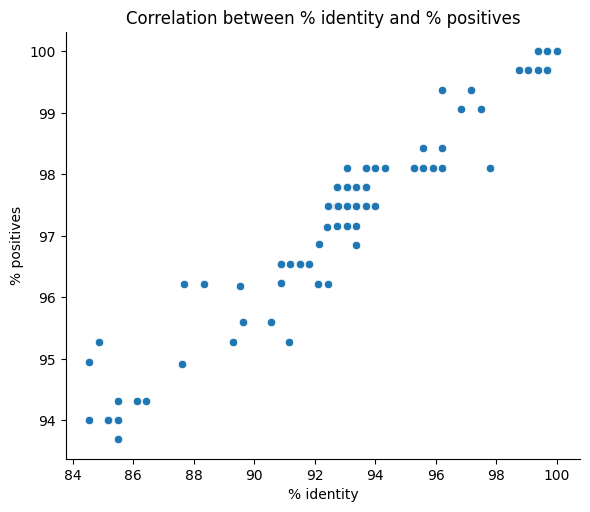

In [20]:
### Your code here . . .
# Create a plot that shows the correlation between % identity and % positives
import seaborn as sns
import matplotlib.pyplot as plt
df[" % identity"] = pd.to_numeric(df["% identity"], errors="coerce")
df["% positives"] = pd.to_numeric(df["% positives"], errors="coerce")
sns.relplot(
    data=df,
    x="% identity",
    y="% positives",
    kind="scatter",
    height=5,
    aspect=1.2
)
plt.title("Correlation between % identity and % positives")


### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [22]:
### Your code here . . .
protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(protein_url)
df = df.merge(
    protein_df,
    how="left",              # keep all rows from  left which is df
    left_index=True,      
    right_on="Protein"       # match Protein column from protein_df
)

# Rename 'Source' to 'Protein source'
df = df.rename(columns={"Source": "Protein source"})

# Drop redundant 'Protein' column
df = df.drop(columns=["Protein"])
df[["Protein source"]].head(10)

,Protein source
NaN,NaN
0.0,RefSeq
NaN,NaN
1.0,GenPept
NaN,NaN
NaN,NaN
NaN,NaN
NaN,NaN
NaN,NaN
NaN,NaN
